In [1]:
import time

import matplotlib.pyplot as plt
import nest
import nest.raster_plot

import numpy as np



             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.10.0
 Built  : Jul 17 2026 15:10:33

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



1.0
Building network
Connecting devices
Connecting network
Excitatory connections
Inhibitory connections
Simulating
Brunel network simulation (Python)
Number of neurons : 5000
Number of synapses: 2515000
       Excitatory : 1615000
       Excitatory_2 : 400000
       Inhibitory : 500000
Excitatory rate 1 : 2.60 Hz
Excitatory rate 2 : 2.60 Hz
Inhibitory rate   : 12.52 Hz
Building time     : 0.54 s
Simulation time   : 6.49 s
1.1
Building network
Connecting devices


/home/alvinw/nest_env/lib/python3.14/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
GetStatus() is deprecated and will be removed in a future version of NEST. Instead of GetStatus(nrns|conns, args), use nrns|conns.get(args).


Connecting network
Excitatory connections
Inhibitory connections
Simulating
Brunel network simulation (Python)
Number of neurons : 5000
Number of synapses: 2515000
       Excitatory : 1615000
       Excitatory_2 : 400000
       Inhibitory : 500000
Excitatory rate 1 : 2.86 Hz
Excitatory rate 2 : 2.69 Hz
Inhibitory rate   : 12.58 Hz
Building time     : 0.67 s
Simulation time   : 8.52 s
1.2
Building network
Connecting devices
Connecting network
Excitatory connections
Inhibitory connections
Simulating
Brunel network simulation (Python)
Number of neurons : 5000
Number of synapses: 2515000
       Excitatory : 1615000
       Excitatory_2 : 400000
       Inhibitory : 500000
Excitatory rate 1 : 3.22 Hz
Excitatory rate 2 : 2.70 Hz
Inhibitory rate   : 12.65 Hz
Building time     : 0.63 s
Simulation time   : 9.39 s
1.3
Building network
Connecting devices
Connecting network
Excitatory connections
Inhibitory connections
Simulating
Brunel network simulation (Python)
Number of neurons : 5000
Number of 

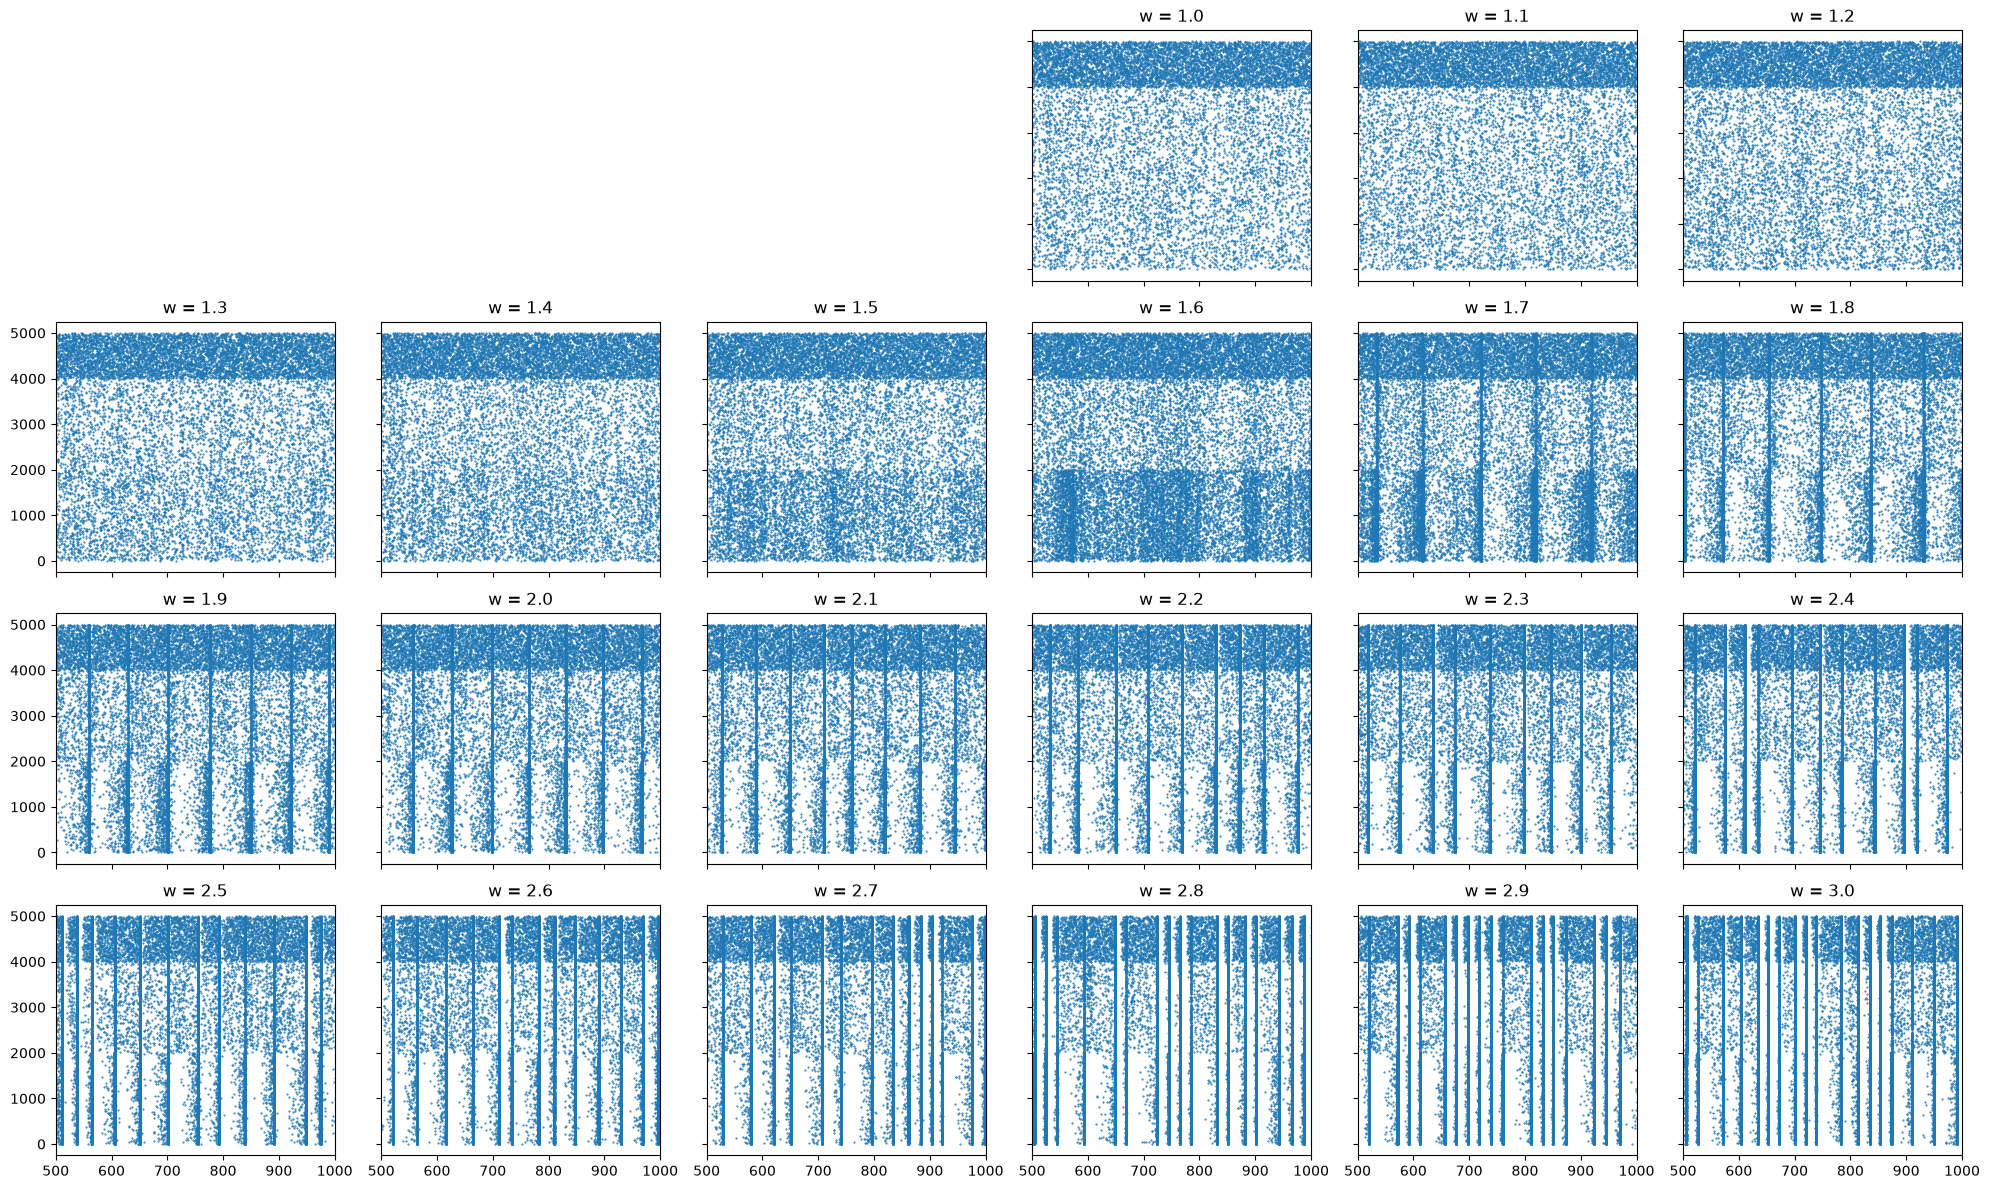

In [ ]:


firingRate_ex_1 = []
firingRate_ex_2 = []
firingRate_in = []
wArr = []

figN = 4
plt.subplots(4, 6, sharex=True, sharey=True, figsize=(20, 12), layout='tight')

plt.subplot(4, 6, 1)
plt.axis('off')
plt.subplot(4, 6, 2)
plt.axis('off')
plt.subplot(4, 6, 3)
plt.axis('off')



for i in range(10, 31, 1):
    w = i / 10

    print(w)

    nest.ResetKernel()
    startbuild = time.time()
    dt = 0.1  # the resolution in ms
    simtime = 1000.0  # Simulation time in ms
    delay = 0.1  # synaptic delay in ms
    g = 10.0  # ratio inhibitory weight/excitatory weight
    eta = 2.0  # external rate relative to threshold rate
    epsilon = 0.1  # connection probability
    order = 1000
    NE_1 = 2 * order  # number of excitatory neurons 1st group
    NE_2 = 2 * order  # number of excitatory neurons 2nd group
    NI = 1 * order  # number of inhibitory neurons
    N_neurons = NE_1 + NE_2 + NI  # number of neurons in total
    N_rec_E = 2000  # record from 50 neurons
    N_rec_I = 1000  # record from 50 neurons

    CE = int(epsilon * NE_1 * 2 )  # number of excitatory synapses per neuron
    CI = int(epsilon * NI  )  # number of inhibitory synapses per neuron
    C_tot = int(CI + CE)  # total number of synapses per neuron
    tauMem = 20.0  # time constant of membrane potential in ms
    theta = 20.0  # membrane threshold potential in mV
    neuron_params = {"C_m": 1.0, "tau_m": tauMem, "t_ref": 2.0, "E_L": 0.0, "V_reset": 0.0, "V_m": 0.0, "V_th": theta}
    J = 0.1  # postsynaptic amplitude in mV
    J_ex = J  # amplitude of excitatory postsynaptic potential
    J_in = -g * J_ex  # amplitude of inhibitory postsynaptic potential
    nu_th = theta / (J * CE * tauMem)
    nu_ex = eta * nu_th
    p_rate = 1000.0 * nu_ex * CE
    nest.resolution = dt
    nest.print_time = True
    nest.overwrite_files = True

    print("Building network")
    # nodes
    nodes_ex_1 = nest.Create("iaf_psc_delta", NE_1, params=neuron_params)
    nodes_ex_2 = nest.Create("iaf_psc_delta", NE_2, params=neuron_params)
    nodes_in = nest.Create("iaf_psc_delta", NI, params=neuron_params)
    parrotNeuron_1 = nest.Create("parrot_neuron")
    parrotNeuron_2 = nest.Create("parrot_neuron")

    # generators
    noise_I = nest.Create("poisson_generator", params={"rate": p_rate})
    noise_E = nest.Create("poisson_generator", params={"rate": p_rate*0.9})
    #poissonForPN_1 = nest.Create("poisson_generator", params={"rate": p_rate*0.1})
    #poissonForPN_2 = nest.Create("poisson_generator", params={"rate": p_rate*0.1})

    # recorders
    espikes_1 = nest.Create("spike_recorder")
    espikes_2 = nest.Create("spike_recorder")
    ispikes = nest.Create("spike_recorder")
    all_spikes = nest.Create("spike_recorder")
    espikes_1.set(label="brunel-py-ex1", record_to="ascii")
    espikes_2.set(label="brunel-py-ex2", record_to="ascii")
    ispikes.set(label="brunel-py-in", record_to="ascii")

    print("Connecting devices")
    nest.CopyModel("static_synapse", "excitatory", {"weight": J_ex, "delay": delay})
    nest.CopyModel("static_synapse", "excitatory_2", {"weight": J_ex * w, "delay": delay})
    nest.CopyModel("static_synapse", "inhibitory", {"weight": J_in, "delay": delay})
    #nest.CopyModel("static_synapse", "inhibitory_2", {"weight": J_in * 10, "delay": delay})

    # connections
    # parrot neurons input
    #nest.Connect(poissonForPN_1, parrotNeuron_1)
    #nest.Connect(poissonForPN_2, parrotNeuron_2)
    #nest.Connect(parrotNeuron_1, nodes_ex_1, syn_spec="excitatory")
    #nest.Connect(parrotNeuron_2, nodes_ex_2, syn_spec="excitatory")

    # possion noise
    nest.Connect(noise_E, nodes_ex_1, syn_spec="excitatory")
    nest.Connect(noise_E, nodes_ex_2, syn_spec="excitatory")
    nest.Connect(noise_I, nodes_in, syn_spec="excitatory")

    # recorder
    nest.Connect(nodes_ex_1[:N_rec_E], espikes_1, syn_spec="excitatory")
    nest.Connect(nodes_ex_2[:N_rec_E], espikes_2, syn_spec="excitatory")
    nest.Connect(nodes_in[:N_rec_I], ispikes, syn_spec="excitatory")
    nest.Connect(nodes_ex_1[:N_rec_E], all_spikes, syn_spec="excitatory")
    nest.Connect(nodes_ex_2[:N_rec_E], all_spikes, syn_spec="excitatory")
    nest.Connect(nodes_in[:N_rec_I], all_spikes, syn_spec="excitatory")
    print("Connecting network")

    print("Excitatory connections")
    conn_params_ex = {"rule": "fixed_indegree", "indegree": 200}
    conn_params_ex_2 = {"rule": "fixed_indegree", "indegree": 200}
    nest.Connect(nodes_ex_1, nodes_ex_1  , conn_params_ex, "excitatory_2")
    nest.Connect(nodes_ex_1, nodes_ex_2 + nodes_in, conn_params_ex, "excitatory")
    nest.Connect(nodes_ex_2, nodes_ex_2 + nodes_in, conn_params_ex, "excitatory")
    nest.Connect(nodes_ex_2, nodes_ex_1, conn_params_ex, "excitatory")

    print("Inhibitory connections")
    conn_params_in = {"rule": "fixed_indegree", "indegree": CI}
    nest.Connect(nodes_in, nodes_ex_1 + nodes_ex_2 + nodes_in, conn_params_in, "inhibitory")
    #nest.Connect(nodes_in, nodes_ex_2 + nodes_in, conn_params_in, "inhibitory")
    endbuild = time.time()
    print("Simulating")

    nest.Simulate(simtime)
    endsimulate = time.time()
    events_ex_1 = espikes_1.n_events
    events_ex_2 = espikes_2.n_events
    events_in = ispikes.n_events
    rate_ex_1 = events_ex_1 / simtime * 1000.0 / N_rec_E
    rate_ex_2 = events_ex_2 / simtime * 1000.0 / N_rec_E
    rate_in = events_in / simtime * 1000.0 / N_rec_I
    num_synapses_ex = nest.GetDefaults("excitatory")["num_connections"]
    num_synapses_ex_2 = nest.GetDefaults("excitatory_2")["num_connections"]
    num_synapses_in = nest.GetDefaults("inhibitory")["num_connections"]
    num_synapses = num_synapses_ex + num_synapses_ex_2 + num_synapses_in
    build_time = endbuild - startbuild
    sim_time = endsimulate - endbuild
    print("Brunel network simulation (Python)")
    print(f"Number of neurons : {N_neurons}")
    print(f"Number of synapses: {num_synapses}")
    print(f"       Excitatory : {num_synapses_ex}")
    print(f"       Excitatory_2 : {num_synapses_ex_2}")
    print(f"       Inhibitory : {num_synapses_in}")
    print(f"Excitatory rate 1 : {rate_ex_1:.2f} Hz")
    print(f"Excitatory rate 2 : {rate_ex_2:.2f} Hz")
    print(f"Inhibitory rate   : {rate_in:.2f} Hz")
    print(f"Building time     : {build_time:.2f} s")
    print(f"Simulation time   : {sim_time:.2f} s")

    
    events = nest.GetStatus(all_spikes)[0]["events"]

    plt.subplot(4, 6, figN)
    plt.plot(events["times"], events["senders"], ".", markersize=1)
    plt.xlim(0, simtime)
    plt.xlim(500, simtime)
    plt.title("w = "+ str(w))
    #plt.savefig('E2I1p_5k_eta2_g7_w'+ str(int(w*10))+  '_all.png')
    figN += 1
    

    firingRate_ex_1.append(rate_ex_1)
    firingRate_ex_2.append(rate_ex_2)
    firingRate_in.append(rate_in)
    wArr.append(w)

plt.savefig('figs/E2I1p_5k_eta2_g10_BG9_wVar_500ms.png')    
plt.show()

a = np.asarray([wArr, firingRate_ex_1, firingRate_ex_2, firingRate_in])
np.savetxt("data/FR_delay01_g10_BG9_wVar_20260806.csv", a, delimiter=",")



In [954]:
print(len(wArr))
print(len(firingRate_ex_1))
print(len(firingRate_ex_2))
print(len(firingRate_in))

21
21
21
21


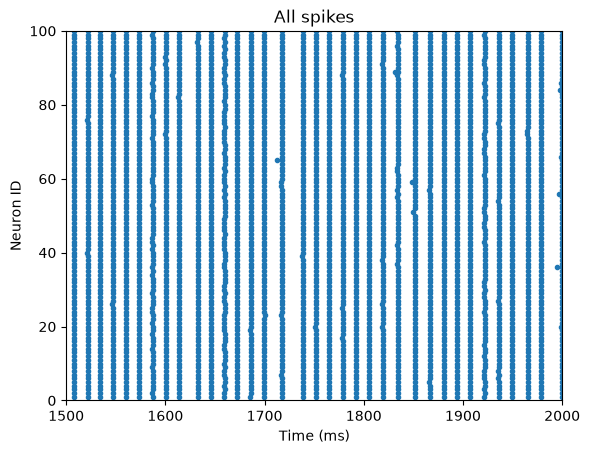

In [15]:
nest.raster_plot.from_device(all_spikes , hist=False, title="All spikes")
plt.xlim(1500, simtime)
plt.ylim(0,100)

plt.show()

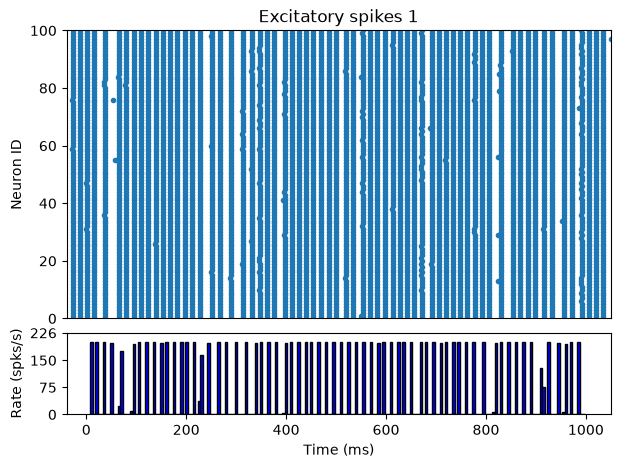

In [9]:
nest.raster_plot.from_device(espikes_1, hist=True, title="Excitatory spikes 1")
plt.xlim(0, simtime)
plt.ylim(0,100)
plt.show()

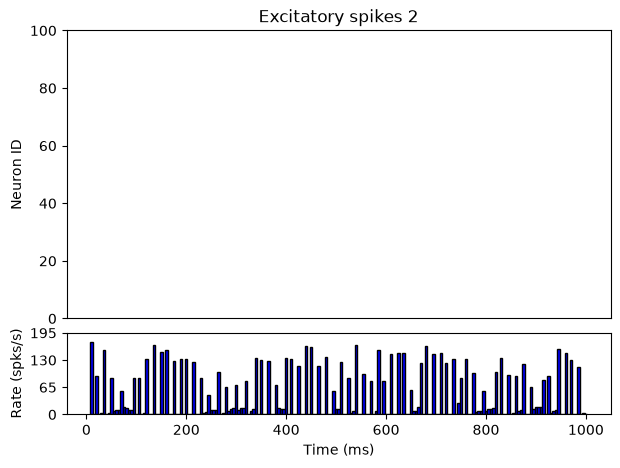

In [10]:
nest.raster_plot.from_device(espikes_2, hist=True, title="Excitatory spikes 2")
plt.xlim(0, simtime)
plt.ylim(0,100)
plt.show()

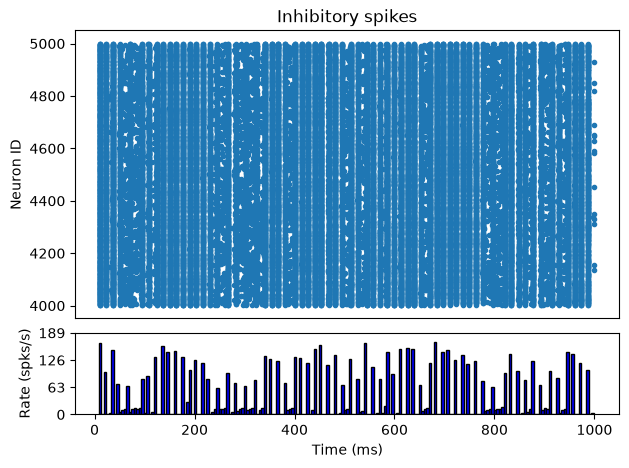

In [11]:
nest.raster_plot.from_device(ispikes, hist=True, title="Inhibitory spikes")
plt.show()

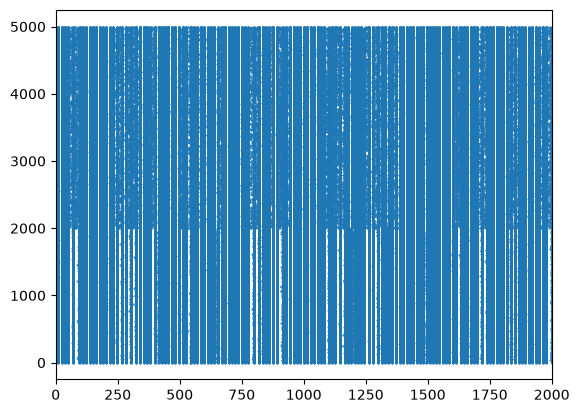

In [21]:
plt.plot(events["times"], events["senders"], ".", markersize=1)
#plt.xlim(0, 500)
#plt.xlim(500, 1000)
#plt.xlim(1000, 1500)
#plt.xlim(1500, simtime)
plt.xlim(0, simtime)
plt.show()